In [30]:
# 数据展示格式设置
import pandas as pd 

# 1.禁止换行
pd.set_option('display.expand_frame_repr',False)

# 2.禁止出现省略号
pd.set_option('display.max_columns',None)

# 读取数据
df = pd.read_csv('../data/heart.csv')
print(df.head())
print(df.info())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  ca  thal  target
0   52    1   0       125   212    0        1      168      0      1.0      2   2     3       0
1   53    1   0       140   203    1        0      155      1      3.1      0   0     3       0
2   70    1   0       145   174    0        1      125      1      2.6      0   0     3       0
3   61    1   0       148   203    0        1      161      0      0.0      2   1     3       0
4   62    0   0       138   294    1        1      106      0      1.9      1   3     2       0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   

In [31]:
# 查看重复行数
print(df.duplicated().sum())

723


In [32]:
# 删除重复行数
df_clean = df.drop_duplicates().reset_index(drop=True)
print(f"打印清洗后的重复行数：{df_clean.duplicated().sum()}")

打印清洗后的重复行数：0


In [33]:
# 查看每列的0值个数
print((df_clean==0).sum(axis=0))

age           0
sex          96
cp          143
trestbps      0
chol          0
fbs         257
restecg     147
thalach       0
exang       203
oldpeak      98
slope        21
ca          175
thal          2
target      138
dtype: int64


In [34]:
# 查看每列的离群值
print(df_clean.describe().loc[['min','mean','max']])

           age       sex        cp    trestbps   chol       fbs  restecg     thalach     exang   oldpeak     slope        ca     thal    target
min   29.00000  0.000000  0.000000   94.000000  126.0  0.000000  0.00000   71.000000  0.000000  0.000000  0.000000  0.000000  0.00000  0.000000
mean  54.42053  0.682119  0.963576  131.602649  246.5  0.149007  0.52649  149.569536  0.327815  1.043046  1.397351  0.718543  2.31457  0.543046
max   77.00000  1.000000  3.000000  200.000000  564.0  1.000000  2.00000  202.000000  1.000000  6.200000  2.000000  4.000000  3.00000  1.000000


In [35]:
# 定义特征与目标
X = df_clean.drop('target',axis=1)
y = df_clean['target']
print(X)
print(y)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  ca  thal
0     52    1   0       125   212    0        1      168      0      1.0      2   2     3
1     53    1   0       140   203    1        0      155      1      3.1      0   0     3
2     70    1   0       145   174    0        1      125      1      2.6      0   0     3
3     61    1   0       148   203    0        1      161      0      0.0      2   1     3
4     62    0   0       138   294    1        1      106      0      1.9      1   3     2
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...    ...  ..   ...
297   68    0   2       120   211    0        0      115      0      1.5      1   0     2
298   44    0   2       108   141    0        1      175      0      0.6      1   0     2
299   52    1   0       128   255    0        1      161      1      0.0      2   1     3
300   59    1   3       160   273    0        0      125      0      0.0      2   0     2
301   54  

In [36]:
# 切分数据
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.head())
print(X_test.head())
print(y_train.head())
print(y_test)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  ca  thal
132   48    1   0       124   274    0        0      166      0      0.5      1   0     3
202   58    1   0       128   259    0        0      130      1      3.0      1   2     3
196   45    0   1       130   234    0        0      175      0      0.6      1   0     2
75    44    1   1       120   220    0        1      170      0      0.0      2   0     2
176   62    0   0       150   244    0        1      154      1      1.4      1   0     2
     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  ca  thal
179   44    1   1       130   219    0        0      188      0      0.0      2   0     2
228   62    0   2       130   263    0        1       97      0      1.2      1   1     3
111   58    0   0       170   225    1        0      146      1      2.8      1   2     1
246   63    1   3       145   233    1        0      150      0      2.3      0   0     1
60    53  

In [37]:
# 数据缩放
from sklearn.preprocessing import StandardScaler

# 1.实例化模型
scaler = StandardScaler()

# 2.缩放数据
X_train_scalered = scaler.fit_transform(X_train)
X_test_scalered = scaler.transform(X_test)


In [38]:
# K值范围
import numpy as np
n_samples = len(X_train_scalered)
max_k = (int(np.sqrt(n_samples))) * 2
print(max_k)
k_range = [i for i in range(1,max_k+2) if i % 2 != 0]
print(k_range)

30
[1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31]


c:\Software\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Software\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30830 (\N{CJK UNIFIED IDEOGRAPH-786E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Software\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Software\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31934 (\N{CJK UNIFIED IDEOGRAPH-7CBE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Software\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21484 (\N{CJK UNIFIED IDEOGRAPH-53EC}) missing from font(s) DejaVu Sans.
  fig.canvas.prin

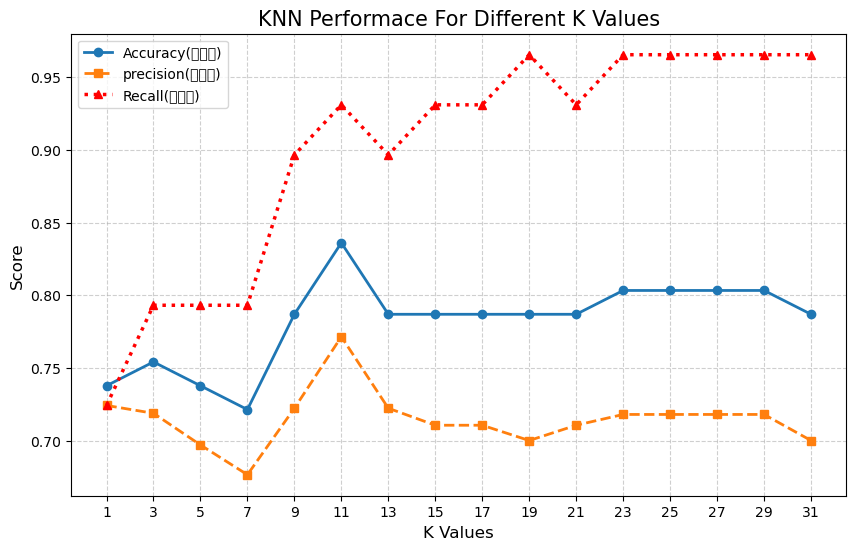

In [39]:
# 计算准确率、精确率、召回率并绘图
from sklearn.metrics import accuracy_score,precision_score,recall_score
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

acc_list = []
pre_list = []
rec_list = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scalered,y_train)
    y_test_pred = knn.predict(X_test_scalered)
    acc_list.append(accuracy_score(y_test,y_test_pred))
    pre_list.append(precision_score(y_test,y_test_pred))
    rec_list.append(recall_score(y_test,y_test_pred))

plt.figure(figsize=(10,6))
plt.plot(k_range,acc_list,label='Accuracy(准确率)',marker='o',linestyle='-',linewidth=2)
plt.plot(k_range,pre_list,label='precision(精确率)',marker='s',linestyle='--',linewidth=2)
plt.plot(k_range,rec_list,label='Recall(召回率)',linestyle=':',marker='^',color='red',linewidth=2.5)

plt.title('KNN Performace For Different K Values',fontsize=15)
plt.xlabel('K Values',fontsize=12)
plt.ylabel('Score',fontsize=12)
plt.xticks(k_range)
plt.legend()
plt.grid(True,linestyle='--',alpha=0.6)
plt.show()

### 🔎 最终决策：选择 K=23
- **决策依据**：在心脏病预测场景下，漏诊成本极高。
- **性能表现**：K=23 进入了指标稳定平台期，召回率（Recall）达到峰值（>96%），虽然准确率比 K=11 略低，但作为辅助诊断工具，其捕捉潜在患者的能力更强。

In [40]:
# 利用最佳K值重新训练模型
knn_final = KNeighborsClassifier(n_neighbors=23)
knn.fit(X_train_scalered,y_train)
y_test_pred_final = knn.predict(X_test_scalered)


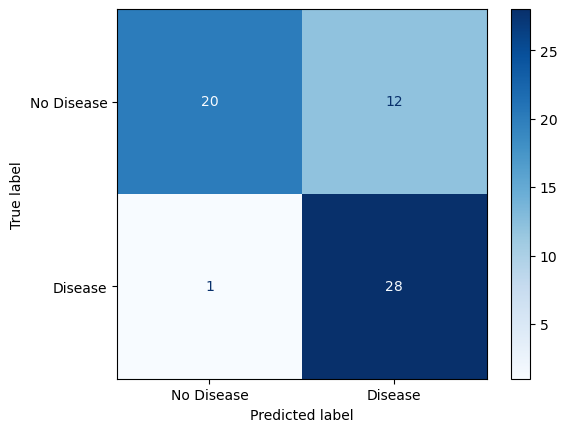

In [41]:
# 利用最佳K值计算混淆矩阵
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

cm = confusion_matrix(y_test,y_test_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['No Disease','Disease'])
disp.plot(cmap='Blues')
plt.show()

In [42]:
# 打印整体模型评估报告
from sklearn.metrics import classification_report

# 打印一份完整的“体检报告”
print(classification_report(y_test, y_test_pred_final, target_names=['No Disease', 'Disease']))


              precision    recall  f1-score   support

  No Disease       0.95      0.62      0.75        32
     Disease       0.70      0.97      0.81        29

    accuracy                           0.79        61
   macro avg       0.83      0.80      0.78        61
weighted avg       0.83      0.79      0.78        61

